## Imports & Setup

In [10]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load Trained Generator

In [5]:
# Define Generator model (same as training)
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super(ResnetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)


In [6]:
class GeneratorResNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, n_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        model = [
            nn.Conv2d(input_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        # Downsampling
        model += [
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(256),
            nn.ReLU(True)
        ]

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResnetBlock(256)]

        # Upsampling
        model += [
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        model += [nn.Conv2d(64, output_channels, kernel_size=7, padding=3), nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [7]:
# Load pre-trained generator (e.g., Summer to Winter)
generator = GeneratorResNet().to(device)
generator.load_state_dict(torch.load('/kaggle/input/cyclegan-summer2winter/pytorch/default/1/generator_A2B.pth', map_location=device))
# Load pre-trained generator (e.g.,Winter to Summer)
#generator.load_state_dict(torch.load('/kaggle/input/cyclegan-summer2winter/pytorch/default/1/generator_B2A.pth', map_location=device))
generator.eval()

GeneratorResNet(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (8): ReLU(inplace=True)
    (9): ResnetBlock(
      (block): Sequential(
        (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride

## Transforms

In [11]:
# Define transform (same as training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


## Denormalization & Inference Function

In [13]:
def denormalize(img_tensor):
    """Convert a normalized tensor image to a NumPy image for display."""
    img = img_tensor.cpu().detach().numpy()
    img = (img * 0.5) + 0.5  # Scale from [-1, 1] to [0, 1]
    img = np.clip(img, 0, 1)  # Ensure valid range
    img = np.transpose(img, (1, 2, 0))  # C, H, W -> H, W, C
    return img.astype(np.float32)
# Translation image
def translate_image(img_path):
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)  # (1, 3, 256, 256)

    with torch.no_grad():
        output_tensor = generator(input_tensor)[0]  # (3, 256, 256)

    output_img = denormalize(output_tensor)  # (256, 256, 3)

    # Display original and translated image
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title("Translated")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


## Display Example Translation

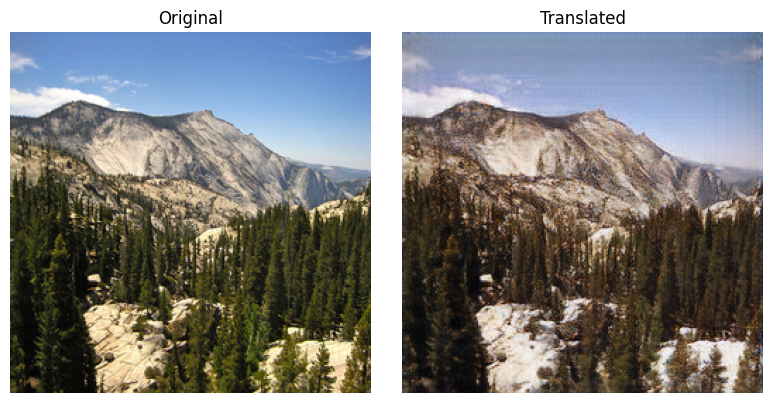

In [15]:
# User can place image path here
example_img_path = '/kaggle/input/summer2winter-yosemite/testA/2011-07-05 11_52_10.jpg'  # <-- User uploads this
translate_image(example_img_path)